# Simulations

In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from engression import engression

from src.dgp import generate_data, make_weak_overlap
#import for simulations
from src.models import *

from src.models import augment_with_engression

In [3]:
df, true_ate = generate_data(n_samples=2000, p=25, seed=538)
df_weak = make_weak_overlap(df, true_ate, gamma=8.0, seed=538)

Samples       : 2000
Covariates    : 25
Treated units : 1010  (50.5%)
Control units : 990  (49.5%)
True ATE      : 1.1028
E[e(X)]       : 0.5000
Y mean        : 1.5759
Y std         : 1.5868
Samples       : 1071  (dropped 929 of 2000)
Gamma         : 8.0
Covariates    : 25
Treated units : 484  (45.2%)
Control units : 587  (54.8%)
True ATE      : 1.1028
E[e(X)]       : 0.4604
Y mean        : 1.6263
Y std         : 1.8322
e(X) < 0.1    : 40.1% of surviving units
e(X) > 0.9    : 30.2% of surviving units
0.1–0.9       : 29.7% of surviving units


# Plotting

We can visualize how this looks like in terms of the first 2 covariates $X_1$ and $X_2$

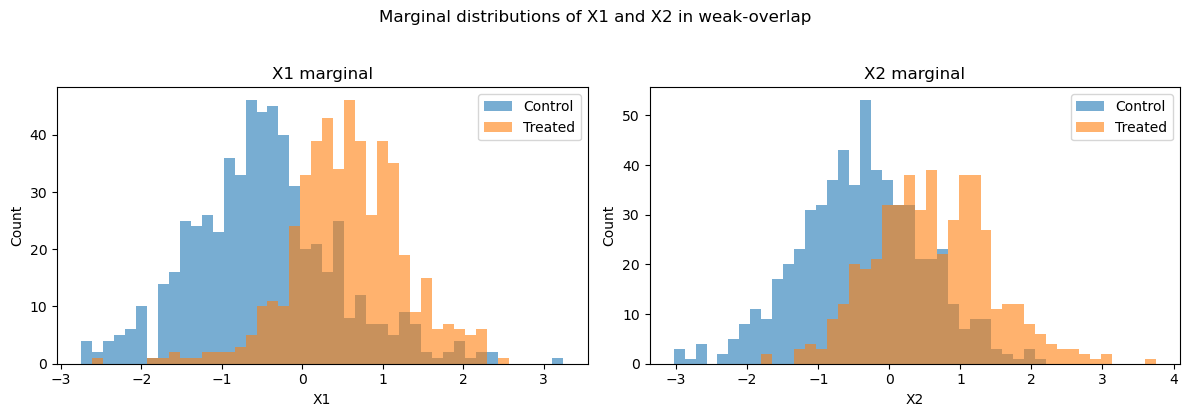

In [4]:
# plot to see how the distributions have shifted

ctrl_weak = df_weak[df_weak["T"] == 0]
trt_weak  = df_weak[df_weak["T"] == 1]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, xvar, title in zip(
    axes,
    ["X1", "X2"],
    ["X1 marginal", "X2 marginal"]
):
    bins = np.linspace(df_weak[xvar].min(), df_weak[xvar].max(), 45)

    ax.hist(ctrl_weak[xvar], bins=bins, alpha=0.6, label="Control", density=False)
    ax.hist(trt_weak[xvar],  bins=bins, alpha=0.6, label="Treated", density=False)

    ax.set_title(title)
    ax.set_xlabel(xvar)
    ax.set_ylabel("Count")
    ax.legend()

plt.suptitle("Marginal distributions of X1 and X2 in weak-overlap", y=1.03)
plt.tight_layout()
plt.show()

it seems like there is a shift and its not bad but we should keep in mind that this is in a 25 dimensional covariate space. Hence the points might be further than we think

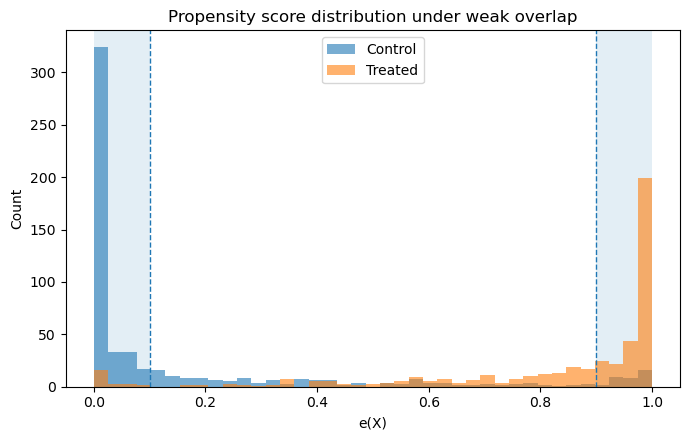

In [5]:
# propensity score plot

bins_ps = np.linspace(0, 1, 40)

plt.figure(figsize=(7, 4.5))

# shade the ends
plt.axvspan(0.0, 0.1, alpha=0.12)
plt.axvspan(0.9, 1.0, alpha=0.12)

# reference lines
plt.axvline(0.1, linestyle="--", linewidth=1)
plt.axvline(0.9, linestyle="--", linewidth=1)

# plot the historgram by group
plt.hist(ctrl_weak["e_x_weak"], bins=bins_ps, alpha=0.6, label="Control")
plt.hist(trt_weak["e_x_weak"],  bins=bins_ps, alpha=0.6, label="Treated")

plt.title("Propensity score distribution under weak overlap")
plt.xlabel("e(X)")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

From this plot, we can really see that there is strong weak overlap as the propensity scores are dense near $0$ and $1$

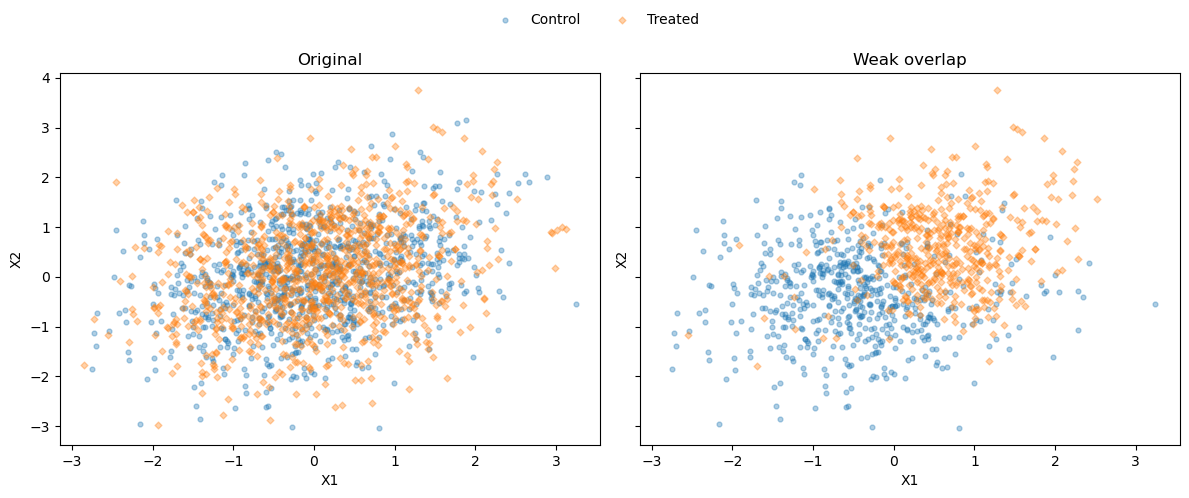

In [6]:
ctrl_orig = df[df["T"] == 0]
trt_orig  = df[df["T"] == 1]
ctrl_weak = df_weak[df_weak["T"] == 0]
trt_weak  = df_weak[df_weak["T"] == 1]

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

axes[0].scatter(ctrl_orig["X1"], ctrl_orig["X2"], s=12, alpha=0.35, label="Control")
axes[0].scatter(trt_orig["X1"],  trt_orig["X2"],  s=12, alpha=0.35, label="Treated", marker="D")
axes[0].set_title("Original")
axes[0].set_xlabel("X1")
axes[0].set_ylabel("X2")

axes[1].scatter(ctrl_weak["X1"], ctrl_weak["X2"], s=12, alpha=0.35, label="Control")
axes[1].scatter(trt_weak["X1"],  trt_weak["X2"],  s=12, alpha=0.35, label="Treated", marker="D")
axes[1].set_title("Weak overlap")
axes[1].set_xlabel("X1")
axes[1].set_ylabel("X2")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2, frameon=False)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

This is the comparison of the distribution of the points before and after weak overlap. As we can tell there is a clear seperation after breaking the dataset even in the $X_1$ and $X_2$ dimension.

# Train Engression Model on Weak Overlap Data

We will trian engression on the the weak overlap data that we generate

In [7]:
eng_model, df_eval, metrics = train_engression(
    df=df,
    df_weak=df_weak,
    num_epochs=500,
    batch_size=min(512, len(df_weak)),
    lr=0.01,
    device="mps",
    verbose=True,
)

Running on CPU.

Data is standardized for training only; the printed training losses are on the standardized scale. 
However during evaluation, the predictions, evaluation metrics, and plots will be on the original scale.

Training based on mini-batch gradient descent with a batch size of 512.
[Epoch 1 (0%), batch 2] energy-loss: 0.6504,  E(|Y-Yhat|): 0.8726,  E(|Yhat-Yhat'|): 0.4444
[Epoch 100 (20%), batch 2] energy-loss: 0.3208,  E(|Y-Yhat|): 0.6772,  E(|Yhat-Yhat'|): 0.7128
[Epoch 200 (40%), batch 2] energy-loss: 0.3078,  E(|Y-Yhat|): 0.6379,  E(|Yhat-Yhat'|): 0.6603
[Epoch 300 (60%), batch 2] energy-loss: 0.2509,  E(|Y-Yhat|): 0.5628,  E(|Yhat-Yhat'|): 0.6238
[Epoch 400 (80%), batch 2] energy-loss: 0.2294,  E(|Y-Yhat|): 0.5178,  E(|Yhat-Yhat'|): 0.5769
[Epoch 500 (100%), batch 2] energy-loss: 0.2251,  E(|Y-Yhat|): 0.4951,  E(|Yhat-Yhat'|): 0.5400

Training loss on the original (non-standardized) scale:
	Energy-loss: 0.4019,  E(|Y-Yhat|): 0.8981,  E(|Yhat-Yhat'|): 0.9923

Prediction

In [8]:
# check the metrics
print(metrics)

{'rmse_mu0': 0.7917262293074769, 'corr_mu0': 0.7530195150632358, 'ate_engression': 1.6818171739578247, 'true_ate': 1.1027718667372697, 'device': 'mps', 'num_epochs': 500, 'batch_size': 512, 'lr': 0.01, 'n_train': 1071, 'n_eval': 2000}


# Baseline Model

We can run a baseline test to see wihtout augmnentation, what are the scores that the modesl will achieve before the augmentation.

In [9]:
X_cols = [c for c in df.columns if c.startswith("X")]

baseline_estimates, baseline_summary = run_simulation(
    sim_df=df_weak,
    x_cols=X_cols,
    true_ate=true_ate,
    eng_model=eng_model,
    n_sims=100,
    seed=538,
    min_group_size=10,
    verbose=True,
)

Running 100 bootstrap simulations...
True ATE = 1.1028

  Sim 20/100 done
  Sim 40/100 done
  Sim 60/100 done
  Sim 80/100 done
  Sim 100/100 done

Done.


In [10]:
print(baseline_summary)

          Estimator      Mean      Bias        SD      RMSE    N
0               OLS  2.150491  1.047719  0.104729  1.052889  100
1               IPW  1.004668 -0.098103  0.130472  0.162717  100
2           AIPW_RF  1.127627  0.024855  0.109736  0.111979  100
3     Causal_Forest  0.981544 -0.121228  0.083827  0.147149  100
4  Engression_Naive  1.683480  0.580708  0.018188  0.580990  100


seems like OLS does very poorly and so does naive engressin. This makes sense since OLS relies of a good covariate support and engression struggles to learn the ATE. 

# Augment Data

## augment 

In [11]:
df_aug = augment_with_engression(
    df_weak=df_weak,
    eng_model=eng_model,
    threshold_low=0.10,
    threshold_high=0.90,
    seed=538,
)

Case 1: 406 control units duplicated as treated
Case 2: 288 treated units duplicated as control

Augmentation summary
Original units        : 1071
Synthetic twins added : 694
Augmented total       : 1765
Treated / Control     : 890 / 875 (50.4% / 49.6%)


In [12]:
aug_estimates, aug_summary = run_simulation(
    sim_df=df_aug,
    x_cols=X_cols,
    true_ate=true_ate,
    eng_model=eng_model,
    n_sims=100,
    seed=538,
)

Running 100 bootstrap simulations...
True ATE = 1.1028

  Sim 20/100 done
  Sim 40/100 done
  Sim 60/100 done
  Sim 80/100 done
  Sim 100/100 done

Done.


In [15]:
print(aug_summary)

          Estimator      Mean      Bias        SD      RMSE    N
0               OLS  1.509963  0.407191  0.059808  0.411516  100
1               IPW  1.510049  0.407277  0.059909  0.411616  100
2           AIPW_RF  1.489054  0.386282  0.048019  0.389226  100
3     Causal_Forest  1.433783  0.331012  0.044528  0.333963  100
4  Engression_Naive  1.502284  0.399512  0.022345  0.400130  100


## Retrain on augmented then eval


In [13]:
eng_model_aug, df_eval_aug, metrics_aug = train_engression(
    df=df,
    df_weak=df_aug,
    num_epochs=500,
    batch_size=min(512, len(df_aug)),
    lr=0.01,
    device="auto",
    verbose=True,
)

Running on CPU.

Data is standardized for training only; the printed training losses are on the standardized scale. 
However during evaluation, the predictions, evaluation metrics, and plots will be on the original scale.

Training based on mini-batch gradient descent with a batch size of 512.
[Epoch 1 (0%), batch 3] energy-loss: 0.6425,  E(|Y-Yhat|): 0.9007,  E(|Yhat-Yhat'|): 0.5163
[Epoch 100 (20%), batch 3] energy-loss: 0.2883,  E(|Y-Yhat|): 0.6369,  E(|Yhat-Yhat'|): 0.6972
[Epoch 200 (40%), batch 3] energy-loss: 0.2348,  E(|Y-Yhat|): 0.5181,  E(|Yhat-Yhat'|): 0.5667
[Epoch 300 (60%), batch 3] energy-loss: 0.2252,  E(|Y-Yhat|): 0.4856,  E(|Yhat-Yhat'|): 0.5208
[Epoch 400 (80%), batch 3] energy-loss: 0.1854,  E(|Y-Yhat|): 0.4137,  E(|Yhat-Yhat'|): 0.4565
[Epoch 500 (100%), batch 3] energy-loss: 0.1730,  E(|Y-Yhat|): 0.3861,  E(|Yhat-Yhat'|): 0.4263

Training loss on the original (non-standardized) scale:
	Energy-loss: 0.2753,  E(|Y-Yhat|): 0.6433,  E(|Yhat-Yhat'|): 0.7360

Prediction

In [14]:
aug_estimates, aug_summary = run_simulation(
    sim_df=df_aug,
    x_cols=X_cols,
    true_ate=true_ate,
    eng_model=eng_model_aug,
    n_sims=100,
    seed=538,
    min_group_size=10,
    verbose=True,
)

Running 100 bootstrap simulations...
True ATE = 1.1028

  Sim 20/100 done
  Sim 40/100 done
  Sim 60/100 done
  Sim 80/100 done
  Sim 100/100 done

Done.


In [16]:
print(aug_summary)

          Estimator      Mean      Bias        SD      RMSE    N
0               OLS  1.509963  0.407191  0.059808  0.411516  100
1               IPW  1.510049  0.407277  0.059909  0.411616  100
2           AIPW_RF  1.489054  0.386282  0.048019  0.389226  100
3     Causal_Forest  1.433783  0.331012  0.044528  0.333963  100
4  Engression_Naive  1.502284  0.399512  0.022345  0.400130  100
